# Ablation Plots

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pickle
import sys

%cd /well/rittscher/users/mju725/trimodal_alignment

project_root = Path.cwd()
sys.path.insert(0, str(project_root))


from ablations_functions import (
    plot_abl_study_lambda_heatmaps,
    plot_rna_representation_delta_tradeoff_gene_reference,
    plot_text_level_ablation
    
)

/well/rittscher/users/mju725/conda/skylake/envs/histomotif_clean/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/exafs1/well/rittscher/users/mju725/trimodal_alignment


/well/rittscher/users/mju725/conda/skylake/envs/histomotif_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
lung_dir = Path("/well/rittscher/users/mju725/trimodal_alignment_objects/lung")
prostate_dir = Path("/well/rittscher/users/mju725/trimodal_alignment_objects/prostate")
figures_dir = Path("/well/rittscher/users/mju725/trimodal_alignment_objects/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

In [3]:
from datetime import datetime
def load_ablation_pickles(dataset_dir):
    paths = sorted((dataset_dir / "ablation_objects").glob("*.pkl"))
    if not paths:
        raise FileNotFoundError(f"No ablation result pickles found in {dataset_dir / 'ablation_objects'}")

    loaded = {}
    for path in paths:
        if "._" in path.name:
            continue
            
        timestamp = path.stat().st_mtime
        date_str = datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d %H:%M:%S')
            
        if path.stat().st_size == 0:
            continue
            
        try:
            with open(path, "rb") as f:
                loaded[path.stem] = pickle.load(f)
        except EOFError:
            print(f"[{date_str}] Skipping corrupted file: {path.name}")
            
    return loaded



all_ablation_results = {
    "lung": load_ablation_pickles(lung_dir)
}

In [4]:
abl_transcriptomic_representation_lung = all_ablation_results["lung"]["abl_abl_transcriptomic_representation_lung"]
abl_lambda_lung = all_ablation_results["lung"]["abl_abl_lambda_sweep_lung"]
abl_reports_lung = all_ablation_results["lung"]["abl_abl_reports_lung"]

## Transcriptomic representation

Ablation showing that fusion improves both Image–RNA alignment and RNA-Text over gene expression alone.

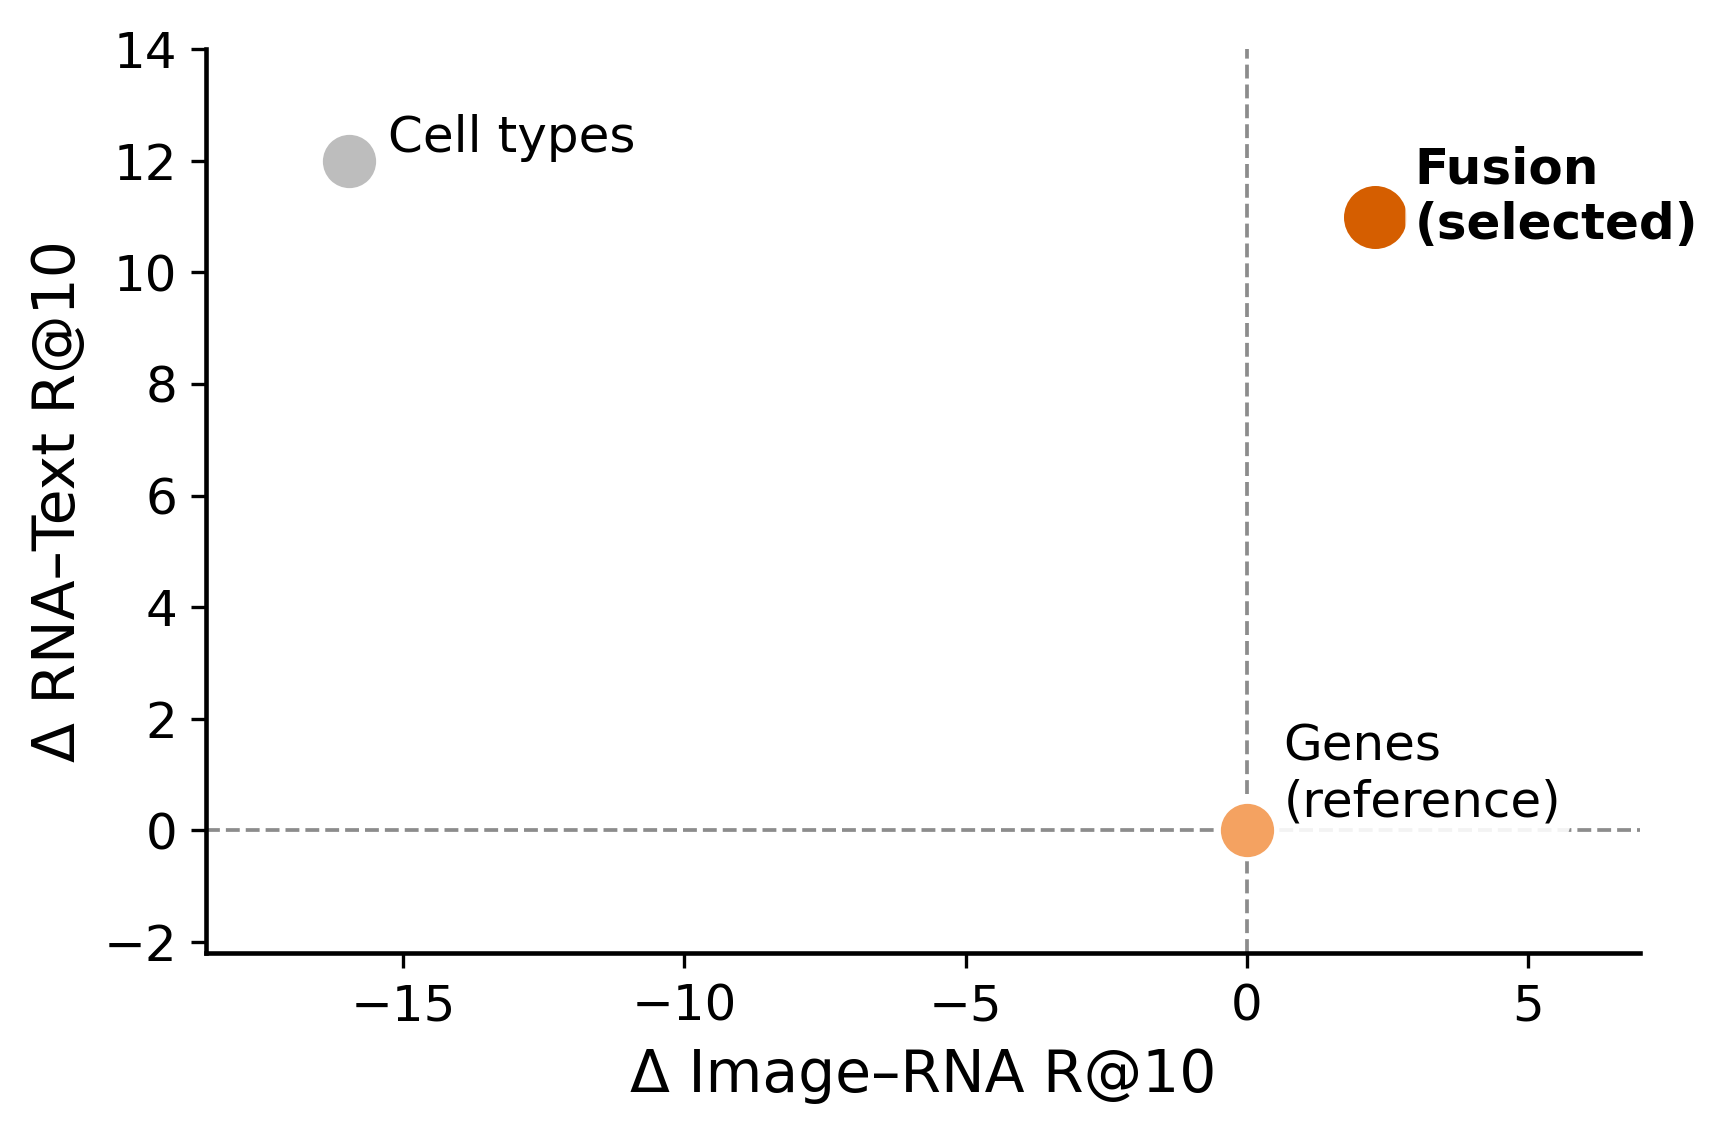

In [9]:
df_b = plot_rna_representation_delta_tradeoff_gene_reference(
    abl_transcriptomic_representation_lung,
    figures_dir,
    out_name="rna_representation_delta_tradeoff_gene_reference",
)

# Lambda sweep

λ sweep showing that semantic anchoring remains relatively stable across a broad range of RNA–Text and Image–Text loss weights.

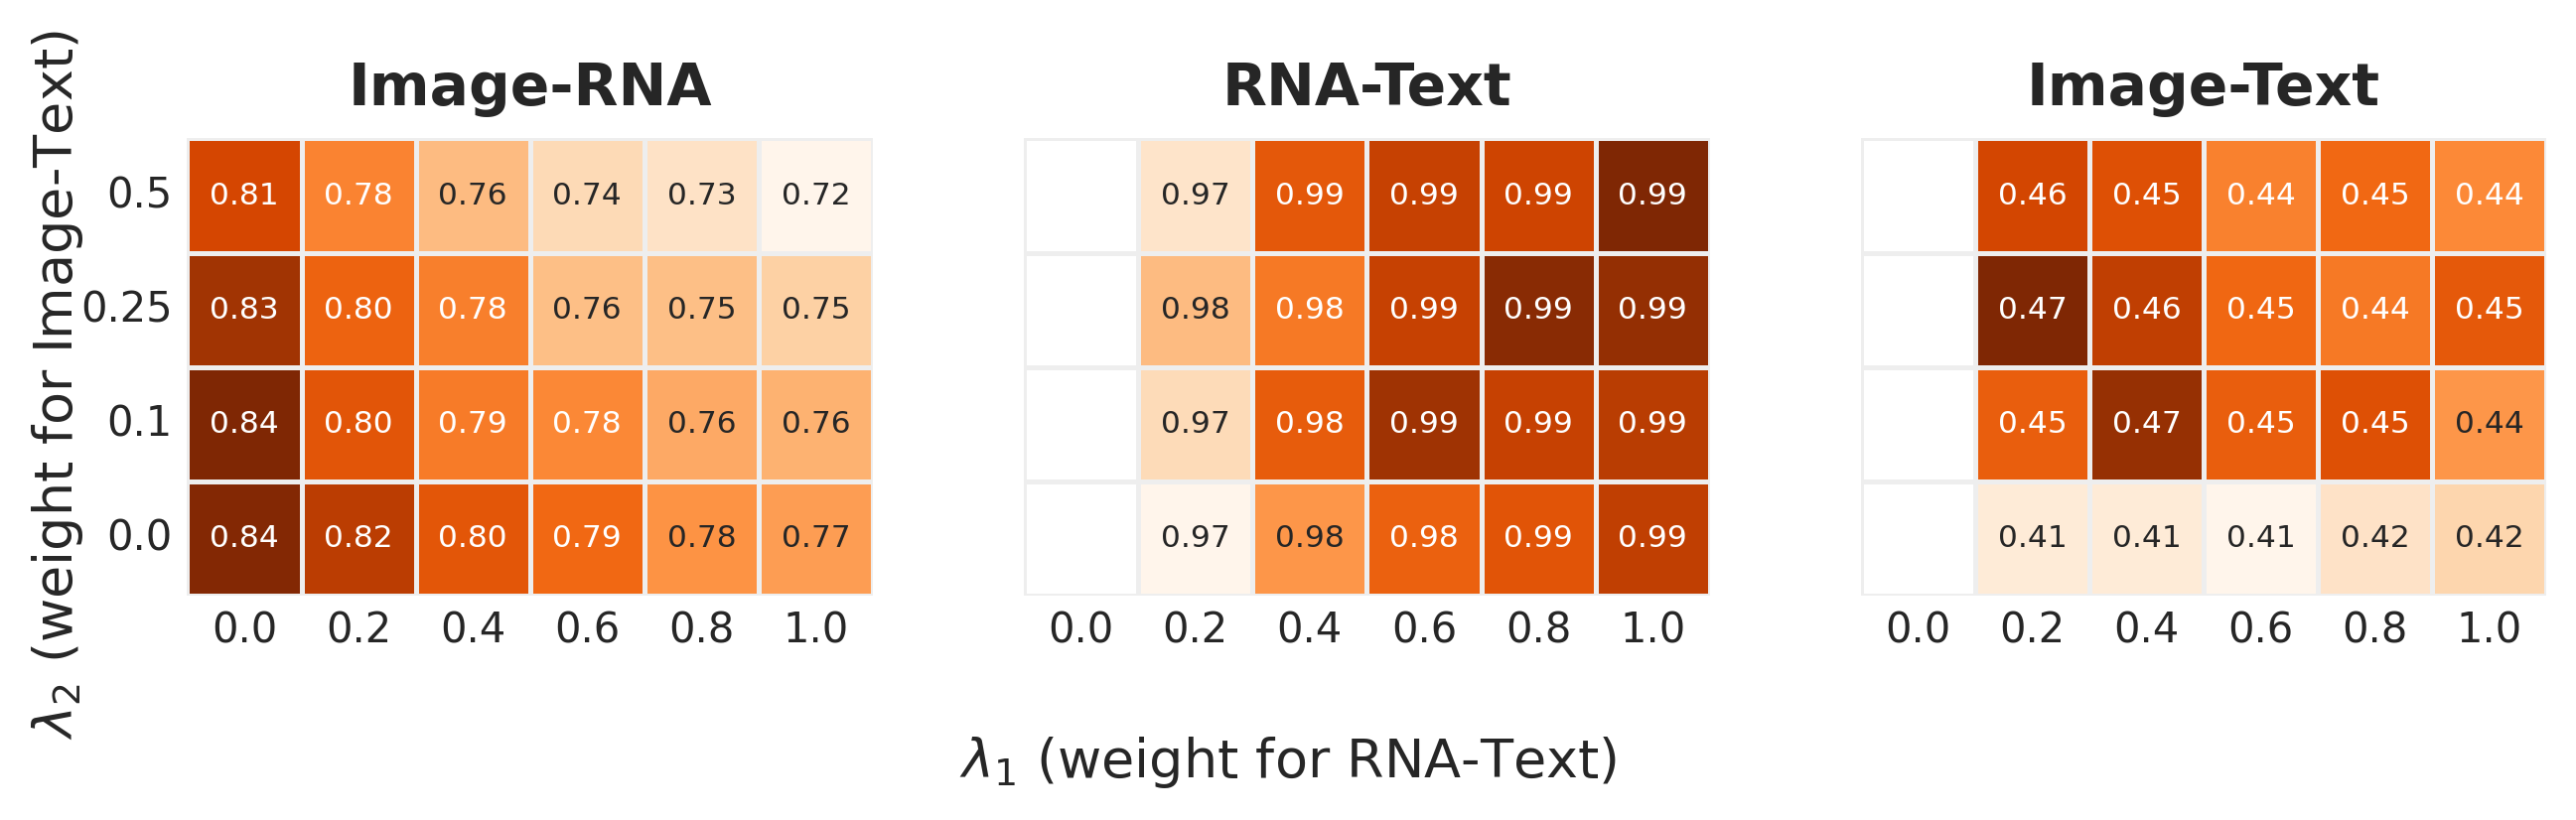

In [17]:
df_lambda_lung, lambda_pivots_lung = plot_abl_study_lambda_heatmaps(
    results_dict=abl_lambda_lung,
    figures_dir=figures_dir,
    out_name="lambda_sensitivity_heatmaps_lung",
    metric="R@10",
    chosen_l1=None,
    chosen_l2=None,
    share_scale=False,
)

## Report granularity

Ablation shows that composition is the strongest standalone anchor (especially for text alignment), while interaction and density cues mainly act as refinements when combined with composition.

T: Image-RNA
T: Image-Text
T: RNA-Text


/exafs1/well/rittscher/users/mju725/trimodal_alignment/ablations_functions.py:799: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


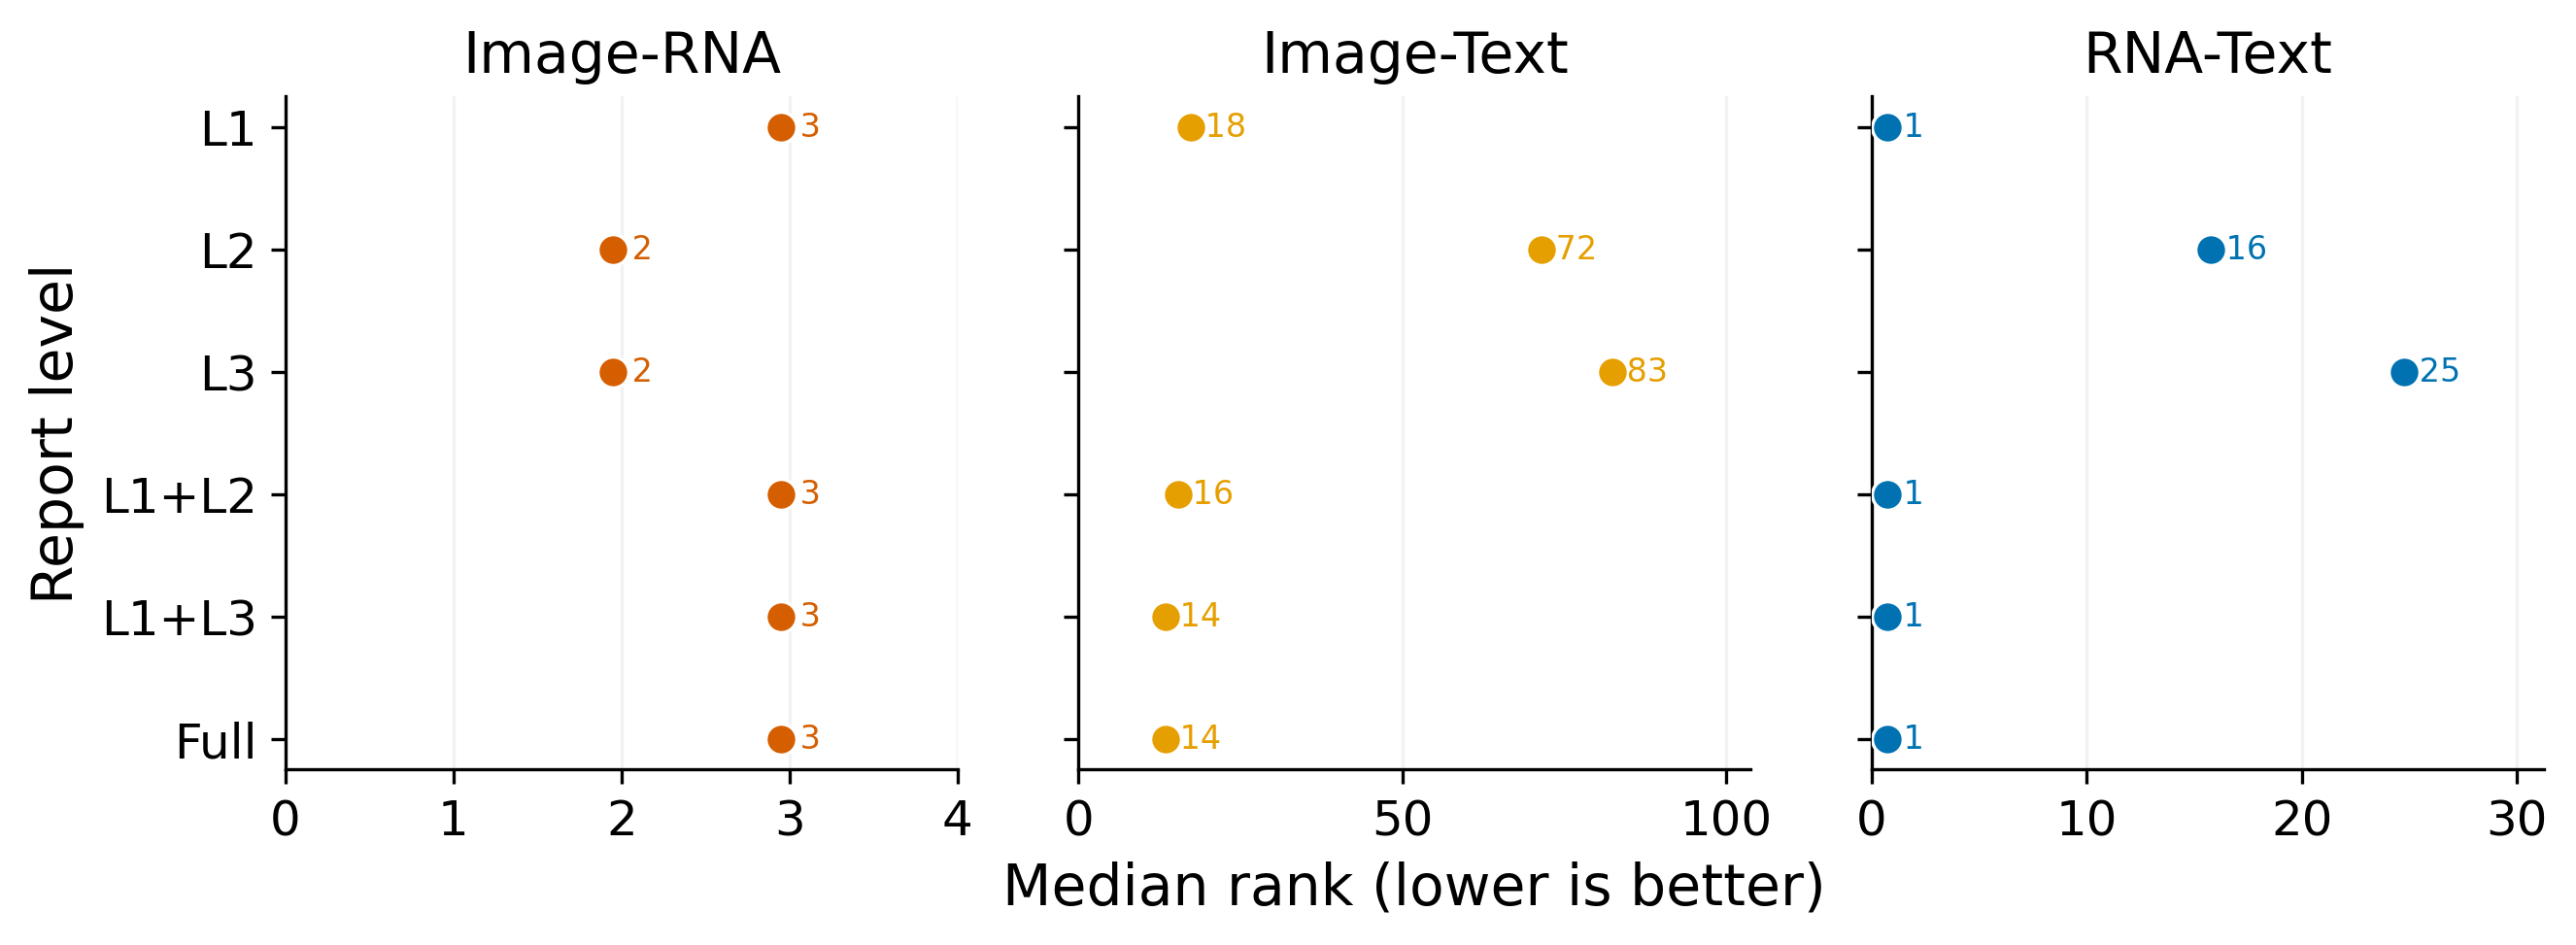

,level,level_label,task,value
0,1,L1,Image-RNA,3
1,1,L1,Image-Text,18
2,1,L1,RNA-Text,1
3,2,L2,Image-RNA,2
4,2,L2,Image-Text,72
5,2,L2,RNA-Text,16
6,3,L3,Image-RNA,2
7,3,L3,Image-Text,83
8,3,L3,RNA-Text,25
9,1_2,L1+L2,Image-RNA,3


In [12]:
plot_text_level_ablation(
    abl_study_results=abl_reports_lung,
    figures_dir=figures_dir,
    out_name="text_level_ablation",
    metric="median_rank",
    annotate=True,
)